In [33]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import PyMieScatt as ps

# Reproducibility — same "random" numbers every run
np.random.seed(42)
torch.manual_seed(42)

theta shape: (181,)
SU shape: (181,)
First few SU values: [274.50568018 273.77890685 271.60879971 268.02578541 263.07987412]


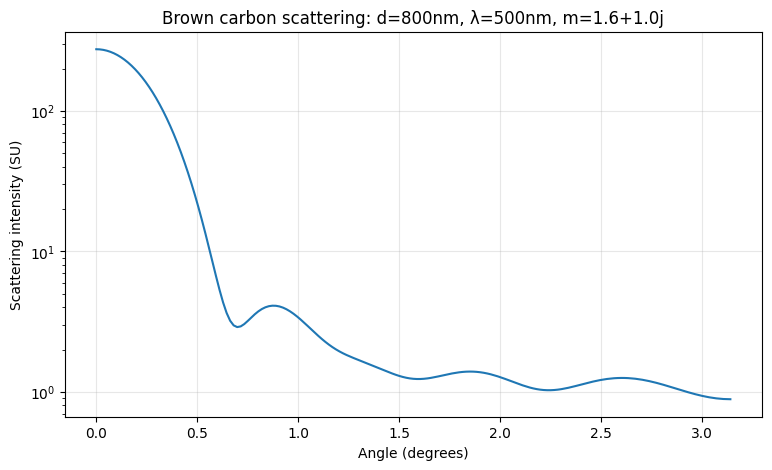

In [34]:
# Brown carbon at the center of our range
n = 1.6
k = 1.0
wavelength = 500   # nm
diameter = 800     # nm

m = complex(n, k)
theta, SL, SR, SU = ps.ScatteringFunction(
    m, wavelength, diameter,
    minAngle=0, maxAngle=180, angularResolution=1
)

print("theta shape:", theta.shape)
print("SU shape:", SU.shape)
print("First few SU values:", SU[:5])

plt.figure(figsize=(9, 5))
plt.plot(theta, SU)
plt.xlabel("Angle (degrees)")
plt.ylabel("Scattering intensity (SU)")
plt.title(f"Brown carbon scattering: d={diameter}nm, λ={wavelength}nm, m=1.6+1.0j")
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()

In [35]:
N_SAMPLES = 1000

# Pre-allocate arrays
inputs = np.zeros((N_SAMPLES, 2))     # 2 features: wavelength, diameter
outputs = np.zeros((N_SAMPLES, 181))  # 181 angles per curve

# Fixed values for brown carbon
n = 1.6
k = 1.0
m = complex(n, k)

print("Generating training data through physics")

for i in range(N_SAMPLES):
    # Sample random wavelength and diameter
    wavelength = np.random.uniform(450, 550)
    diameter = np.random.uniform(700, 900)
    
    # Run Mie calculation, we'll treat this as the accurate data
    theta, SL, SR, SU = ps.ScatteringFunction(
        m, wavelength, diameter,
        minAngle=0, maxAngle=180, angularResolution=1
    )
    
    # Store inputs and outputs
    inputs[i] = [wavelength, diameter]
    outputs[i] = SU
    
    if i % 100 == 0:
        print(f"  {i}/{N_SAMPLES} done")

print("\nDone!")
print("Inputs shape:", inputs.shape)
print("Outputs shape:", outputs.shape)

Generating training data through physics
  0/1000 done
  100/1000 done
  200/1000 done
  300/1000 done
  400/1000 done
  500/1000 done
  600/1000 done
  700/1000 done
  800/1000 done
  900/1000 done

Done!
Inputs shape: (1000, 2)
Outputs shape: (1000, 181)


took 4 minutes and 20 seconds for mie theory calculations for 10000 samples

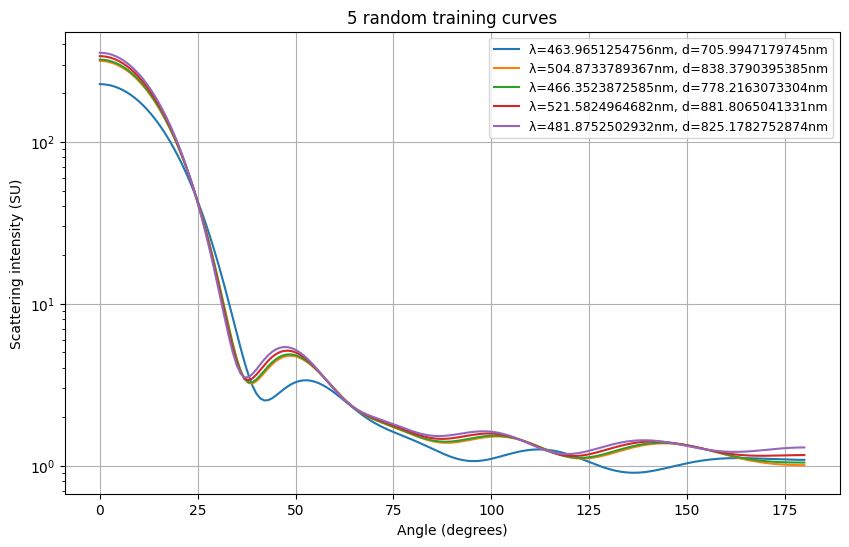

In [36]:
plt.figure(figsize=(10, 6))

# Plot 5 random curves
indices = np.random.choice(N_SAMPLES, 5, replace=False)

# generate lables for each line
for i in indices:
    label = f"λ={inputs[i,0]:.10f}nm, d={inputs[i,1]:.10f}nm"
    plt.plot(outputs[i], label=label)

plt.xlabel("Angle (degrees)")
plt.ylabel("Scattering intensity (SU)")
plt.title("5 random training curves")
plt.yscale('log')
plt.legend(fontsize=9)
plt.grid(True, alpha=1.0)
plt.show()

graphed 5 random training data points, just to see the shape of the results

In [37]:
# 1. Log-transform the outputs
log_outputs = np.log10(outputs)   # base-10 log

# 2. Normalize the inputs to roughly [0, 1]
# wavelength: 450-550 → (wavelength - 450) / 100
# diameter:   700-900 → (diameter - 700) / 200
inputs_norm = np.zeros_like(inputs)
inputs_norm[:, 0] = (inputs[:, 0] - 450) / 100   # wavelength
inputs_norm[:, 1] = (inputs[:, 1] - 700) / 200   # diameter

# 3. Train/test split — first 800 train, last 200 test
X_train = inputs_norm[:800] # contains wavelength and diameter
y_train = log_outputs[:800] # amount of light at each angle, values have had log applied
X_test = inputs_norm[800:]
y_test = log_outputs[800:]

# Convert to PyTorch tensors
X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train)
X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print()
print("Sample input (normalized):", X_train[0])

X_train shape: torch.Size([800, 2])
y_train shape: torch.Size([800, 181])
X_test shape: torch.Size([200, 2])
y_test shape: torch.Size([200, 181])

Sample input (normalized): tensor([0.3745, 0.9507])


Split the data into training and testing data, formatting the data so it's ready for training. Converting numpy arrays into Tensors.

In [62]:
model = nn.Sequential(
    nn.Linear(2, 128),       # input layer: 2 features → 64 neurons
    nn.ReLU(),
    nn.Linear(128, 256),     # hidden layer: 64 → 128
    nn.ReLU(),
    nn.Linear(256, 256),     # output layer: 128 → 181 (one per angle)
    nn.ReLU(),
    nn.Linear(256, 181),
)

print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params}")

Sequential(
  (0): Linear(in_features=2, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=256, bias=True)
  (3): ReLU()
  (4): Linear(in_features=256, out_features=256, bias=True)
  (5): ReLU()
  (6): Linear(in_features=256, out_features=181, bias=True)
)

Total parameters: 145717


building NN layers, applying ReLu between each. Printing the model and counting the number of parameters.

In [63]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
loss_fn = nn.MSELoss()
print("Optimizer:", optimizer)
print("Loss function:", loss_fn)

Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)
Loss function: MSELoss()


In [64]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

print("Optimizer:", optimizer)
print("Loss function:", loss_fn)

Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
Loss function: MSELoss()


In [65]:
N_EPOCHS = 200
BATCH_SIZE = 32

train_losses = []
test_losses = []

n_train = X_train.shape[0]   # 800
n_batches = n_train // BATCH_SIZE  # 800 // 32 = 25

print(f"Training: {N_EPOCHS} epochs, {n_batches} batches per epoch\n")

for epoch in range(N_EPOCHS):
    # Shuffle training data each epoch
    perm = torch.randperm(n_train)# generates a random permutation of the numbers up to 800
    X_shuffled = X_train[perm] # shuffle the training data according to the permutation
    y_shuffled = y_train[perm] # shuffle the 'answers' for the training data
    
    # Train one epoch (one pass through the data, in mini-batches)
    epoch_loss = 0.0
    for i in range(n_batches):
        start = i * BATCH_SIZE # index work to see where batch starts
        end = start + BATCH_SIZE # index work to see where each batch ends while looping through the batches
        X_batch = X_shuffled[start:end] # diameters and wavelengths used in this batch
        y_batch = y_shuffled[start:end] # light scattered at each angle in this batch
        
        # Standard 5-step training pattern
        pred = model(X_batch) # predict
        loss = loss_fn(pred, y_batch) # get the loss
        
        optimizer.zero_grad() # clears gradients from previous batches
        loss.backward() # back propagation to compute gradients for all weights
        optimizer.step() #updates all weights using the gradients
        
        epoch_loss += loss.item() # records the loss over the batches for graphing
    
    avg_train_loss = epoch_loss / n_batches # average across all 25 batches
    train_losses.append(avg_train_loss) # save avg loss for plotting
    
    # Evaluate on test set (no gradients needed)
    with torch.no_grad():
        test_pred = model(X_test) #predict on 200 test examples
        test_loss = loss_fn(test_pred, y_test).item() #compute MSE on test set
        test_losses.append(test_loss) # save it
    
    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d}  Train Loss: {avg_train_loss:.10f}  Test Loss: {test_loss:.10f}")

print("\nTraining complete!")

Training: 200 epochs, 25 batches per epoch

Epoch   0  Train Loss: 0.3468234884  Test Loss: 0.0386449955
Epoch  20  Train Loss: 0.0003126520  Test Loss: 0.0002802308
Epoch  40  Train Loss: 0.0000394018  Test Loss: 0.0000357388
Epoch  60  Train Loss: 0.0000224359  Test Loss: 0.0000177422
Epoch  80  Train Loss: 0.0000165568  Test Loss: 0.0000154446
Epoch 100  Train Loss: 0.0000144609  Test Loss: 0.0000107033
Epoch 120  Train Loss: 0.0000156636  Test Loss: 0.0000100420
Epoch 140  Train Loss: 0.0001277191  Test Loss: 0.0001092051
Epoch 160  Train Loss: 0.0000118956  Test Loss: 0.0000279929
Epoch 180  Train Loss: 0.0000101450  Test Loss: 0.0000116795

Training complete!


Training the model. Randomizing the sequence of the training set. Split the set into a training and testing set. Also making sure loss is decreasing over time, ensuring we are approaching a minimum in the cost. Training took 10.7 seconds


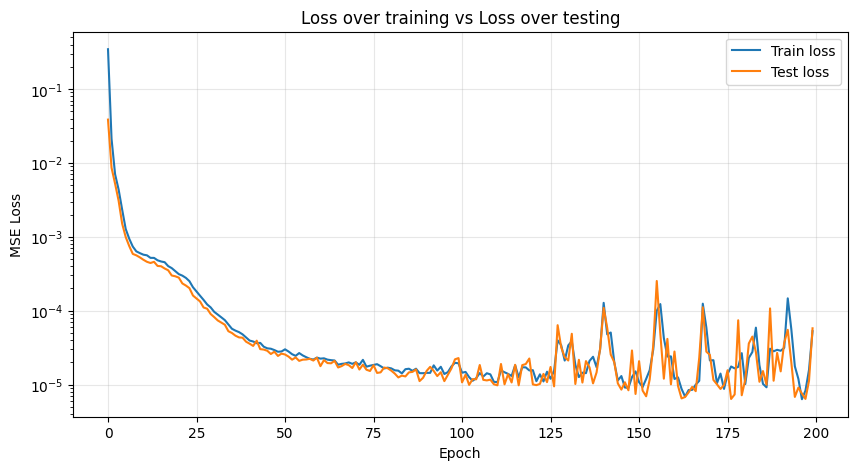

In [66]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train loss')
plt.plot(test_losses, label='Test loss')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Loss over training vs Loss over testing")
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

tensor([2.5626, 2.5613, 2.5573, 2.5507, 2.5414, 2.5295, 2.5148, 2.4973, 2.4771,
        2.4541, 2.4281, 2.3992, 2.3673, 2.3322, 2.2940, 2.2524, 2.2074, 2.1588,
        2.1064, 2.0502, 1.9898, 1.9252, 1.8560, 1.7820, 1.7030, 1.6186, 1.5287,
        1.4330, 1.3317, 1.2249, 1.1136, 0.9995, 0.8859, 0.7783, 0.6841, 0.6118,
        0.5674, 0.5517, 0.5596, 0.5827, 0.6133, 0.6453, 0.6750, 0.7004, 0.7203,
        0.7345, 0.7428, 0.7455, 0.7429, 0.7353, 0.7232, 0.7069, 0.6870, 0.6640,
        0.6384, 0.6107, 0.5817, 0.5520, 0.5223, 0.4931, 0.4652, 0.4390, 0.4151,
        0.3936, 0.3746, 0.3581, 0.3439, 0.3317, 0.3210, 0.3115, 0.3027, 0.2944,
        0.2862, 0.2779, 0.2694, 0.2607, 0.2518, 0.2428, 0.2339, 0.2254, 0.2174,
        0.2102, 0.2040, 0.1990, 0.1954, 0.1931, 0.1923, 0.1927, 0.1943, 0.1968,
        0.2001, 0.2037, 0.2075, 0.2111, 0.2143, 0.2169, 0.2186, 0.2193, 0.2189,
        0.2173, 0.2144, 0.2102, 0.2047, 0.1980, 0.1903, 0.1816, 0.1720, 0.1618,
        0.1513, 0.1406, 0.1300, 0.1198, 

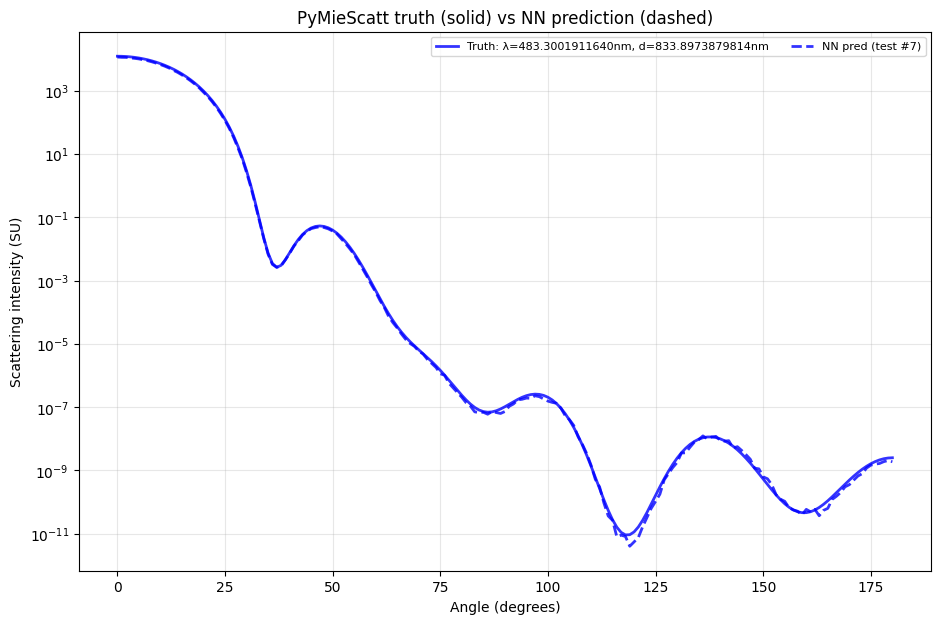

In [67]:
with torch.no_grad():
    test_pred = model(X_test)

# Plot 4 random test cases
plt.figure(figsize=(11, 7))
indices = np.random.choice(len(X_test), 1, replace=False)

print(y_test[indices[0]])
print(test_pred[indices[0]])

# Use different colors for each pair so they're visually distinguishable
colors = ['blue', 'orange', 'green', 'red']

for idx, color in zip(indices, colors):

    # Get the actual physical values (un-normalize)
    norm_w = X_test[idx, 0].item()
    norm_d = X_test[idx, 1].item()
    real_w = norm_w * 100 + 450
    real_d = norm_d * 200 + 700
    
    # Convert log10 back to real brightness values
    true_curve = y_test[idx].numpy() ** 10 # take the log output brightness values and turn them back to their original values
    pred_curve = test_pred[idx].numpy() ** 10 # take the prediction values and turn them back to their original values
    
    # Solid line = truth (PyMieScatt), Dashed line = NN prediction
    plt.plot(true_curve, '-',  color=color, linewidth=2, alpha=0.8,
             label=f"Truth: λ={real_w:.10f}nm, d={real_d:.10f}nm")
    plt.plot(pred_curve, '--', color=color, linewidth=2, alpha=0.8,
             label=f"NN pred (test #{idx})")

plt.xlabel("Angle (degrees)")
plt.ylabel("Scattering intensity (SU)")
plt.title("PyMieScatt truth (solid) vs NN prediction (dashed)")
plt.yscale('log')
plt.legend(fontsize=8, ncol=2)
plt.grid(True, alpha=0.3)
plt.show()

Todo: Still have to try out the tan h compression function between layers. Try to 

Mean squared error (in log space): 3.501521e-03


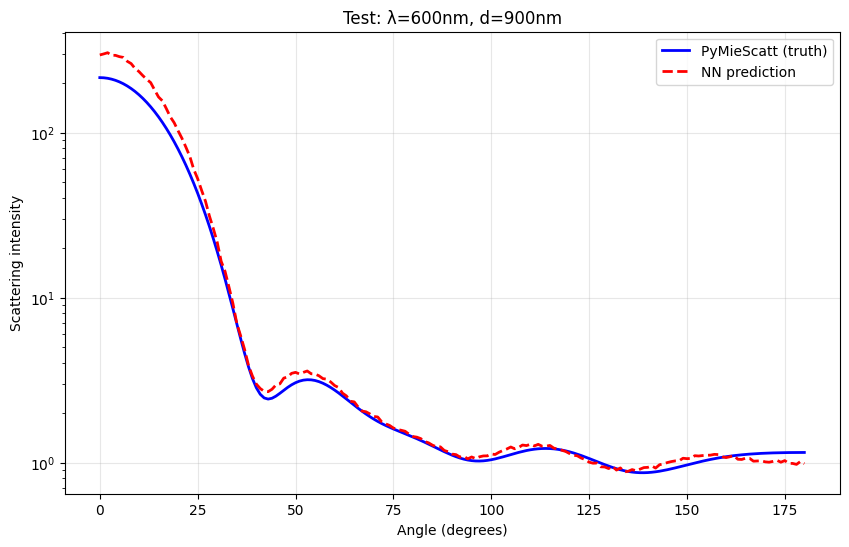

In [68]:
def predict_scattering(wavelength, diameter):
    """Predict scattering curve for a given wavelength and diameter."""
    # Normalize the inputs the same way we did during training
    norm_wavelength = (wavelength - 450) / 100
    norm_diameter   = (diameter - 700) / 200
    
    # Convert to tensor with shape (1, 2) — one example, two features
    input_tensor = torch.FloatTensor([[norm_wavelength, norm_diameter]])
    
    # Run through the network
    with torch.no_grad():
        log_pred = model(input_tensor)
    
    # Convert from log space back to real brightness
    pred_curve = 10 ** log_pred.numpy().flatten()
    
    return pred_curve


def true_scattering(wavelength, diameter):
    """Compute the actual PyMieScatt scattering curve."""
    m = complex(1.6, 1.0)  # brown carbon
    theta, SL, SR, SU = ps.ScatteringFunction(
        m, wavelength, diameter,
        minAngle=0, maxAngle=180, angularResolution=1
    )
    return SU


# Pick any wavelength and diameter to test
test_wavelength = 600  # nm
test_diameter = 900    # nm

# Get both predictions
nn_curve = predict_scattering(test_wavelength, test_diameter)
true_curve = true_scattering(test_wavelength, test_diameter)

# Calculate error
error = np.mean((np.log10(nn_curve) - np.log10(true_curve))**2)
print(f"Mean squared error (in log space): {error:.6e}")

# Plot
plt.figure(figsize=(10, 6))
plt.plot(true_curve, '-',  color='blue', linewidth=2, label='PyMieScatt (truth)')
plt.plot(nn_curve,   '--', color='red',  linewidth=2, label='NN prediction')
plt.xlabel("Angle (degrees)")
plt.ylabel("Scattering intensity")
plt.title(f"Test: λ={test_wavelength}nm, d={test_diameter}nm")
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

still understanding this part... work in progress. Doesn't look too accurate though. The neural network is able to predict values within it's trained range very well. As soon as it is given a value that is not within the trained range, it starts to perform more poorly. Values within the training range are predicted very accurately. If the neural network is asked to predict with wavelength and diameter outside of the training range, it is more inaccurate.